# Plan dump + trace overlay — `PlanDumpRequest`/`PlanRecord` vs streamed `MotionTrace`

**Ticket 100-009** (SUC-011): a developer sends `PlanDumpRequest` (`CommandEnvelope`
arm 18) against a REAL tier-1 sim run and gets back one `PlanRecord` (`ReplyEnvelope`
arm `plan`) per ring entry; arms `StreamControl.trace` and gets a `MotionTrace`
(arm `trace`) push per TLM period alongside the regular `Telemetry` push. This
notebook plots the dumped plan's FULL reference table (`Drive::MotionPlan::
referenceAt()`, tier 0 — the smooth curve `source/drive/` itself would draw before
anything moves) against the streamed `MotionTrace` samples' own `ref_x`/`ref_y`
points (should sit exactly ON the curve — same compiled code, different path to
it) and the sim's actual fused pose (`Telemetry.pose`) at each sample (showing
the tracker's real-world tracking error).

No hardware — tier-1 sim (`tests/_infra/sim`) driven over the SAME binary wire
protocol a real robot speaks, plus tier 0 (`tests/_infra/drive`) for the
reference-table overlay.

In [1]:
import pathlib
import subprocess
import sys

import pandas as pd

_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "tests" / "_infra" / "drive").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")

SIM_INFRA = REPO / "tests" / "_infra" / "sim"
DRIVE_INFRA = REPO / "tests" / "_infra" / "drive"
UNIT_DIR = REPO / "tests" / "sim" / "unit"
HOST_DIR = REPO / "host"
OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in (SIM_INFRA, DRIVE_INFRA, UNIT_DIR, HOST_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Build both host libraries -- fast (no codegen dependency beyond what
# gen_messages.py/gen_pb2.py already produced in source/ and host/).
subprocess.run(["just", "build-sim"], cwd=REPO, check=True)
subprocess.run(["just", "build-drive"], cwd=REPO, check=True)

from firmware import Sim  # noqa: E402
from _binary_envelope import CHANNEL_SERIAL, dearmor, send, send_no_tick  # noqa: E402
from robot_radio.robot.pb2 import envelope_pb2 as pb_envelope  # noqa: E402
from robot_radio.robot.pb2 import motion_pb2 as pb_motion  # noqa: E402
from drive import Drive, Goal, Limits, PlanRequest, Pose, ProfileLimits, Verdict  # noqa: E402

print(f"REPO = {REPO}")

# 077-001 / 081-004: gen_default_config.py writes to source/robot/
# DefaultConfig.cpp -- a directory the greenfield rebuild's new source/
# tree deliberately does not (yet) create. build.py already guards this
# structurally (see its own 077-001 comment); this recipe had never been
# updated to match, so it hard-failed the moment tests/_infra/sim/
# existed for this recipe to reach the cmake steps below. Mirror
# build.py's guard here so it self-heals the same way once source/robot/
# reappears.
if [ -d source/robot ]; then uv run python3 scripts/gen_default_config.py; fi
uv run python3 scripts/gen_messages.py
gen_messages: kMaxEncodedSize report (095-005 Step 0c):
  //   CommandEnvelope: drive=56B, segment=83B, replace=83B, config=109B, pose_fix=27B, otos=19B, ping=2B, echo=68B, get=4B, stream=12B, stop=2B, id=162B, hello=2B, ver=3B, help=3B, plan_dump=3B (worst=id=162B) + non-oneof=6B => total=168B
  //   ReplyEnvelope: ok=19B, err=10B, tlm=165B, cfg=111B, evt=20B, id=162B, echo=68B

gen_pb2: wrote 14 pb2 module(s) to host/robot_radio/robot/pb2
uv run python3 scripts/gen_boot_config.py
gen_boot_config: wrote source/config/boot_config.cpp
# 2026-07-11: bake the CURRENT pyproject version into the sim dylib too
# (source/types/version_generated.h). Without this, `VER` from a sim
# session reports whatever version the header held at some prior full
# build -- which defeats the stale-sim provenance handshake the
# wheel_motion_trace notebook (and any other sim client) relies on to
# detect a long-lived kernel still holding an old in-process dylib.
uv run python3 scripts/gen_version.py
cmake -S tests/_infra/sim -B tests/_infra/sim/build -DROBOT_RUN_MODE=SIM


-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/_infra/sim/build


cmake --build tests/_infra/sim/build --parallel


[  2%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/kinematics/body_kinematics.cpp.o
[  4%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/motion/jerk_trajectory.cpp.o
[  6%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/motion/stop_condition.cpp.o
[  8%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/motion/segment_executor.cpp.o
[ 11%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/subsystems/drivetrain.cpp.o
[ 13%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/telemetry/telemetry_tick.cpp.o
[ 15%] Building CXX object CMakeFiles/firmware_host.dir/Volumes/Proj/proj/RobotProjects/radio-robot-elite/source/subsystems/sim_hardware.cpp.o


[ 46%] Linking CXX shared library libfirmware_host.dylib
[100%] Built target firmware_host


cmake -S tests/_infra/drive -B tests/_infra/drive/build
cmake --build tests/_infra/drive/build --parallel


-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/_infra/drive/build


[100%] Built target drive_host
REPO = /Volumes/Proj/proj/RobotProjects/radio-robot-elite


## Sim-matching `Drive::Limits`

Mirrors `tests/_infra/sim/sim_api.cpp`'s own `defaultSimMotionConfig()`/
`defaultSimDrivetrainConfig()` EXACTLY (NOT `tests/sim/drive/_common.py`'s
tier-0-test-only numbers) — the tier-0 `Drive` used for the reference-table
overlay below must be configured identically to the sim's own adapter, or the
two curves have no reason to agree.

In [2]:
SIM_TRACKWIDTH = 128.0  # [mm] Hal::PhysicsWorld::kDefaultTrackwidth
STEP = 24  # [ms] sim physics tick granularity
TRACE_PERIOD = 450  # [ms] StreamControl.period -- spreads samples across the WHOLE plan
N_SAMPLES = 8  # 8*450=3600ms > this plan's own ~3.2s duration -- covers start to settle

GOAL = Goal(arc_length=600.0, delta_heading=0.4, exit_speed=0.0)


def sim_matching_limits() -> Limits:
    return Limits(
        linear=ProfileLimits(velocity=380.0, accel=800.0, decel=800.0, jerk=5000.0),
        rotational=ProfileLimits(velocity=6.0, accel=20.0, decel=20.0, jerk=100.0),
        v_wheel_max=350.0, trim_v_max=60.0, trim_omega_max=1.0, wheel_step_max=150.0,
        track_k_s=2.0, track_k_theta=6.0, track_k_cross=1.5e-5, min_speed=10.0,
    )

## Drive the sim: admit the segment, dump the plan, stream the trace

In [3]:
import base64

sim = Sim()

# 1. Arm binary telemetry + MotionTrace BEFORE any motion (StreamControl.trace,
#    100-009's own new field) -- see telemetry_tick.cpp: one `tlm` push then,
#    since trace is armed, one `trace` push, same pass, same period.
arm_reply = send(sim, pb_envelope.CommandEnvelope(
    corr_id=9000, stream=pb_envelope.StreamControl(binary=True, trace=True, period=TRACE_PERIOD)))
assert arm_reply.WhichOneof("body") == "ok"

# 2. Admit the segment (wire admission, admitSegment() -- synchronous at
#    route time) WITHOUT its own trailing tick.
seg = pb_motion.MotionSegment(arc_length=GOAL.arc_length, delta_heading=GOAL.delta_heading,
                               exit_speed=GOAL.exit_speed, primitive=True)
seg_reply = send_no_tick(sim, pb_envelope.CommandEnvelope(corr_id=1, segment=seg))
assert seg_reply.WhichOneof("body") == "ok", seg_reply

# ONE tick: drains bb.segmentIn -> ring_ -> starts the plan (Subsystems::
# Drivetrain::tick()'s own step 2 + startNextPlan()) -- without this,
# bb.hasActivePlan is still false and PlanDumpRequest has nothing to dump.
sim.tick_for(STEP)

# 3. PlanDumpRequest -- one PlanRecord per ring entry (just the one active
#    plan here -- nothing else queued).
dump_env = pb_envelope.CommandEnvelope(corr_id=42, plan_dump=pb_envelope.PlanDumpRequest())
dump_line = "*B" + base64.b64encode(dump_env.SerializeToString()).decode("ascii")
dump_reply_lines = sim.command_on(dump_line, CHANNEL_SERIAL)
plan_records = [dearmor(line).plan for line in dump_reply_lines.splitlines() if line.strip()]
print(f"PlanDumpRequest -> {len(plan_records)} PlanRecord(s)")
for i, r in enumerate(plan_records):
    print(f"  [{i}] anchor=({r.anchor.x:.1f},{r.anchor.y:.1f},{r.anchor.h:.3f}) "
          f"goal=({r.goal.x:.1f},{r.goal.y:.1f},{r.goal.h:.3f}) "
          f"v_eff={r.v_eff:.1f} duration={r.duration:.3f}s "
          f"exit_speed={r.exit_speed:.1f} entry_speed={r.entry_speed:.1f} "
          f"replan_count={r.replan_count}")

plan_table_df = pd.DataFrame([{
    "anchor_x": r.anchor.x, "anchor_y": r.anchor.y, "anchor_h": r.anchor.h,
    "goal_x": r.goal.x, "goal_y": r.goal.y, "goal_h": r.goal.h,
    "v_eff": r.v_eff, "duration": r.duration, "exit_speed": r.exit_speed,
    "entry_speed": r.entry_speed, "replan_count": r.replan_count,
} for r in plan_records])
plan_table_df.to_csv(OUT_DIR / "plan_dump_trace_overlay_plandump.csv", index=False)
plan_table_df

PlanDumpRequest -> 1 PlanRecord(s)
  [0] anchor=(0.0,0.0,0.000) goal=(584.1,118.4,0.400) v_eff=216.8 duration=3.199s exit_speed=0.0 entry_speed=0.0 replan_count=0


,anchor_x,anchor_y,anchor_h,goal_x,goal_y,goal_h,v_eff,duration,exit_speed,entry_speed,replan_count
0,0.0,0.0,0.0,584.127502,118.408531,0.4,216.751923,3.199081,0.0,0.0,0


In [4]:
# 4. Tick forward across the WHOLE plan (TRACE_PERIOD-spaced pushes),
#    collecting N_SAMPLES (tlm, trace) pairs spread start-to-settle.
sim.tick_for(N_SAMPLES * TRACE_PERIOD, STEP)
raw = sim.drain_reply_store(CHANNEL_SERIAL)
lines = [line for line in raw.splitlines() if line.strip()]
assert len(lines) % 2 == 0 and len(lines) > 0, f"expected an even, nonzero line count, got {len(lines)}"
replies = [dearmor(line) for line in lines]
tlm_frames = [r.tlm for r in replies[0::2]]
trace_frames = [r.trace for r in replies[1::2]]
print(f"collected {len(trace_frames)} (tlm, trace) sample pairs across the plan's own "
      f"{N_SAMPLES * TRACE_PERIOD / 1000.0:.1f}s tick window")

trace_df = pd.DataFrame([{
    "t": tr.t, "ref_x": tr.ref_x, "ref_y": tr.ref_y, "ref_theta": tr.ref_theta,
    "ref_v": tr.ref_v, "ref_omega": tr.ref_omega, "e_along": tr.e_along, "e_cross": tr.e_cross,
    "wheel_left": tr.wheel_left, "wheel_right": tr.wheel_right, "status": tr.status,
    "actual_x": tlm.pose.x, "actual_y": tlm.pose.y, "actual_h": tlm.pose.h,
} for tr, tlm in zip(trace_frames, tlm_frames)])
trace_df.to_csv(OUT_DIR / "plan_dump_trace_overlay_trace.csv", index=False)
trace_df

collected 7 (tlm, trace) sample pairs across the plan's own 3.6s tick window


,t,ref_x,ref_y,ref_theta,ref_v,ref_omega,e_along,e_cross,wheel_left,wheel_right,status,actual_x,actual_y,actual_h
0,0.456,52.124859,0.905961,0.034757,216.751923,0.144501,-4.563728,0.067127,216.258392,235.500366,0,53.068520,1.009903,0.037500
1,0.912,150.719467,7.591367,0.100649,216.751923,0.144501,-1.519722,0.241389,210.847092,228.735641,0,154.426422,8.219382,0.104255
2,1.368,248.659882,20.754129,0.166542,216.751923,0.144501,-0.618156,0.233524,209.060562,226.915909,0,253.168655,21.762571,0.171000
3,1.824,345.521118,40.337296,0.232435,216.751923,0.144501,-0.141650,0.408748,208.450226,225.620209,0,350.362610,41.920769,0.237060
4,2.280,440.882660,66.255753,0.298327,216.751923,0.144501,0.060307,0.505942,207.577744,225.684860,0,445.757141,68.294167,0.302190
5,2.736,534.330627,98.397110,0.364220,216.751923,0.144501,0.246527,0.476522,206.906525,225.611206,0,539.263550,100.794350,0.366810
6,3.192,584.127258,118.408356,0.400000,0.125362,0.000084,5.204633,0.408979,0.474571,-0.474571,0,588.665222,120.770866,0.401250


## Tier-0 reference table (the full plan, before/independent of any `step()`)

Built from the SAME `Goal` this notebook sent over the wire, planned with a
tier-0 `Drivetrain` configured identically to the sim's own adapter (see
`sim_matching_limits()` above) — `referenceAt(t)` sampled densely over
`[0, duration]`.

In [5]:
with Drive(sim_matching_limits(), SIM_TRACKWIDTH) as drive:
    request = PlanRequest(goal=GOAL, start=Pose())
    result = drive.plan(request)
    assert result.verdict == Verdict.OK, result.verdict
    with result.plan as plan:
        duration = plan.duration()
        rows = []
        n = 200
        for i in range(n):
            t = duration * i / (n - 1) if n > 1 else 0.0
            ref = plan.reference_at(t)
            rows.append({"t": t, "x": ref.x, "y": ref.y, "theta": ref.theta, "v": ref.v})
        ref_table_df = pd.DataFrame(rows)

ref_table_df.to_csv(OUT_DIR / "plan_dump_trace_overlay_reftable.csv", index=False)
print(f"duration={duration:.3f}s  rows={len(ref_table_df)}")
ref_table_df.head()

duration=3.199s  rows=200


,t,x,y,theta,v
0,0.000000,0.000000,0.0,0.000000,0.000000
1,0.016076,0.003462,0.0,0.000002,0.646077
2,0.032152,0.027697,0.0,0.000018,2.584309
3,0.048227,0.093476,0.0,0.000062,5.814695
4,0.064303,0.221572,0.0,0.000148,10.337236


## The overlay plot

Smooth curve = the tier-0 `referenceAt()` table (the dumped plan's full reference
polyline). Circles = the streamed `MotionTrace` samples' own `ref_x`/`ref_y` — they
should sit exactly ON the curve (same compiled `source/drive/` code, same solved
plan). Crosses = the sim's actual fused pose (`Telemetry.pose`) at each sample —
the tracker's real-world tracking error against the reference.

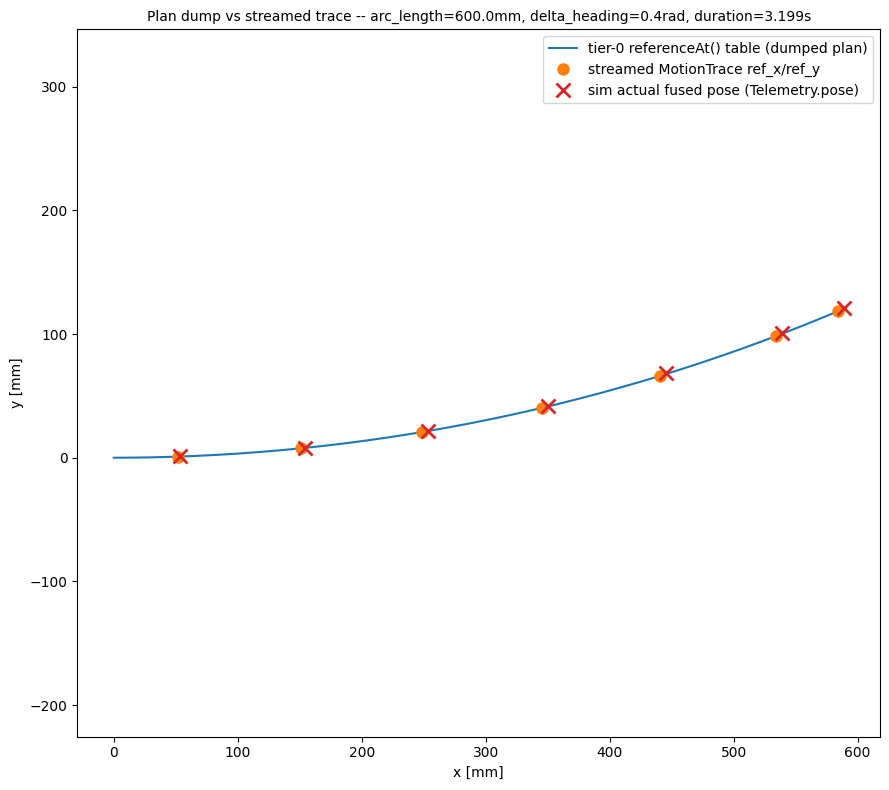

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(ref_table_df["x"], ref_table_df["y"], "-", color="tab:blue", lw=1.5,
        label="tier-0 referenceAt() table (dumped plan)")
ax.plot(trace_df["ref_x"], trace_df["ref_y"], "o", color="tab:orange", ms=8,
        label="streamed MotionTrace ref_x/ref_y")
ax.plot(trace_df["actual_x"], trace_df["actual_y"], "x", color="tab:red", ms=10, mew=2,
        label="sim actual fused pose (Telemetry.pose)")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title(f"Plan dump vs streamed trace -- arc_length={GOAL.arc_length}mm, "
             f"delta_heading={GOAL.delta_heading}rad, duration={duration:.3f}s", fontsize=10)
ax.axis("equal")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "plan_dump_trace_overlay.png", dpi=110)
plt.show()

sim.close()

## Reading the plot

- The orange circles (streamed `MotionTrace.ref_x`/`ref_y`) land exactly on the
  blue reference curve — the SAME `source/drive/` code produced both, reached
  two different ways (the wire, through the wafer adapter; tier 0, through the
  ctypes ABI directly). This is `PlanDumpRequest`/`MotionTrace` doing their job:
  a developer can see "what the robot intends to do" (the dumped plan table) and
  overlay "what the robot's own telemetry says it is doing, per tick" (the
  streamed trace), with no firmware code change between the two views.
- The red crosses (the sim's actual fused pose) show the tracker's real
  closed-loop tracking error against the reference — small at these gains/plant
  settings (matching the sprint's own `k_theta=6.0` proven convergence).

Outputs written to `tests/notebooks/out/`:
`plan_dump_trace_overlay_{plandump,trace,reftable}.csv` and
`plan_dump_trace_overlay.png`.